# 🌲🔷 Random Forests & Support Vector Machines for CNV & Mutation Analysis

Welcome! In this notebook we will learn **two of the most useful machine-learning
models for genomic data** and apply them to a real classification problem:
*given a patient's copy-number (CNV) and mutation profile, predict whether they
have the disease.*

We will meet two very different "thinking styles":

| Model | Core idea in one line |
|-------|----------------------|
| 🌲 **Random Forest** | Ask hundreds of simple decision trees and take a vote. |
| 🔷 **Support Vector Machine (SVM)** | Draw the single boundary that separates the two groups with the widest possible gap. |

Along the way we will also see **why ordinary linear regression is the wrong tool
for this kind of yes/no question**, and how to **tune** both models so they perform
their best.

> 🧬 **Who is this for?** Biologists who are new to machine learning. We keep the
> maths light and lean on biological intuition. Every code cell has a plain-English
> explanation right above it.

---

### 🗺️ Roadmap

- **Part 0 — Foundations:** classification vs. regression, *why linear regression fails*, and the intuition behind Random Forests vs. SVMs.
- **Part 1 — Setup:** load the data, explore it, split it, and build a quick baseline.
- **Part 2 — Random Forest:** how it works → train → tune → read feature importance.
- **Part 3 — Support Vector Machine:** how it works → why scaling matters → train → tune.
- **Part 4 — Head-to-head:** compare all models and decide which to trust.

# Part 0 — Foundations 🧠

Before touching a single model, let's get three ideas straight. This part has almost
no code — it builds the mental picture everything else rests on.

## 0.1 A quick reminder: classification vs. regression

You have already met the idea of **supervised learning** — learning a rule from
labelled examples. There are two flavours, and knowing which one you're in decides
*everything* about which model and which metrics you use.

| | **Regression** | **Classification** |
|---|---|---|
| Predicts | a **number** on a continuous scale | a **category / label** |
| Genomic example | "What is this tumour's expression level of *MYC*?" | "Does this patient have the disease — yes or no?" |
| Output looks like | `4.71`, `-0.3`, `188.0` | `Disease` / `No disease` (often coded `1` / `0`) |

> 🎯 **Our task in this notebook is CLASSIFICATION.** The `Outcome` column is `1`
> (disease) or `0` (no disease). Keep that in mind — it is the reason the next
> section matters so much.

## 0.2 Why *linear regression* is the wrong tool here ❌

You've already used **logistic regression** for classification. But a very natural
question is: *why not just use ordinary **linear regression** to predict the 0/1
outcome?* After all, `0` and `1` are numbers — why not fit a straight line to them?

Let's actually **try it and watch it break.** This is the most important lesson in
Part 0, so we'll run a small demo instead of just talking about it.

**The plan of the demo below:**
1. Take one informative feature and fit a plain `LinearRegression` to the 0/1 outcome.
2. Plot the fitted line on top of the data.
3. Look at what the line *predicts* — and notice the problems.

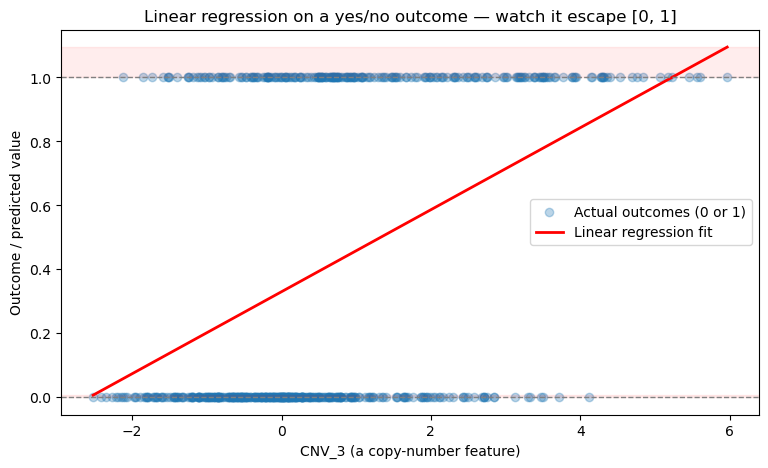

Smallest value the line predicts: 0.006
Largest value the line predicts:  1.095


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load the data early just for this demo (we'll load it "properly" in Part 1).
demo = pd.read_csv("synthetic_cnv_mutation_data.csv")

# Use one continuous feature (a CNV) to keep the picture 2-D and easy to see.
x = demo[["CNV_3"]].values          # predictor (one column)
y = demo["Outcome"].values          # target: 0 or 1

# Fit ordinary linear regression: it tries to draw a straight line through the 0s and 1s.
linreg = LinearRegression().fit(x, y)

# Ask the line to predict across the full range of CNV_3 values.
x_grid = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
y_line = linreg.predict(x_grid)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, alpha=0.3, label="Actual outcomes (0 or 1)")
plt.plot(x_grid, y_line, color="red", linewidth=2, label="Linear regression fit")
plt.axhline(1, color="grey", linestyle="--", linewidth=1)
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.axhspan(1, y_line.max(), color="red", alpha=0.07)      # impossible zone (> 1)
plt.axhspan(y_line.min(), 0, color="red", alpha=0.07)      # impossible zone (< 0)
plt.xlabel("CNV_3 (a copy-number feature)")
plt.ylabel("Outcome / predicted value")
plt.title("Linear regression on a yes/no outcome — watch it escape [0, 1]")
plt.legend()
plt.show()

print("Smallest value the line predicts:", round(y_line.min(), 3))
print("Largest value the line predicts: ", round(y_line.max(), 3))

### What just went wrong? 🚨

Look at the red line and the shaded zones:

1. **Predictions leave the [0, 1] range.** The line dips **below 0** and rises
   **above 1** (see the printed min/max). But a probability of disease can never be
   `-0.2` or `1.3` — those values are meaningless. Linear regression has no idea that
   the outcome is bounded.

2. **There is no probability interpretation.** With logistic regression, an output of
   `0.8` means "80% chance of disease." A linear-regression output of `0.8` is just…
   a point on a line. It was never designed to be a probability.

3. **It is fooled by "how far", not "which side".** Linear regression tries to
   minimise squared distance to every point. A patient who is *very obviously* diseased
   (far to one side) drags the line around just to reduce that distance, even though for
   a yes/no decision all that matters is **which side of the boundary** they fall on.

> 🧬 **The takeaway.** Linear regression answers *"how much?"*, but classification
> asks *"which class?"*. Forcing a straight line onto 0/1 labels gives nonsensical,
> unbounded outputs. **Logistic regression** fixes this by bending the line into an
> S-shaped curve (the *sigmoid*) that stays neatly between 0 and 1 — which is exactly
> why it, and the tree- and margin-based models below, are the right family of tools.

We won't re-teach logistic regression here — you've seen it — but we *will* use it in
Part 1 as a familiar **baseline** to compare Random Forests and SVMs against.

## 0.3 Meet the two stars: Random Forest vs. SVM 🌲🔷

Both models do classification well, but they "think" in completely different ways.
Here's the intuition before we see any code.

### 🌲 Random Forest — *"a committee of simple rules"*

Imagine asking **hundreds of junior lab members** to each make a quick yes/no call
using a few simple rules ("if CNV_3 is amplified AND MUT_5 is present → disease").
Each individual is weak and a bit random, but when you **let them all vote and take
the majority**, the crowd is surprisingly accurate and robust. That crowd of decision
**trees** is a *forest*.

- ✅ Handles messy, high-dimensional genomic data well.
- ✅ Doesn't care about the *scale* of features (mixing binary mutations and continuous CNVs is fine).
- ✅ Tells you **which features mattered** (feature importance) — great for biology.

### 🔷 Support Vector Machine — *"the widest safe street"*

An SVM ignores the crowd and instead looks for **one clean dividing line** between the
two classes — specifically, the boundary that leaves the **widest possible empty gap**
(the *margin*) between the diseased and healthy patients. The few patients sitting right
on the edge of that gap are called **support vectors**; they alone define the boundary.

- ✅ Very effective when the two groups are separable, even in high dimensions.
- ✅ Can bend the boundary into curves using the **kernel trick** (Part 3).
- ⚠️ **Sensitive to feature scale** — we must standardise the data first (Part 3 shows why).

> 🧭 **Rule of thumb we'll test ourselves:** Random Forests are the easy-to-interpret
> workhorse; SVMs can squeeze out strong boundaries but need careful preprocessing and
> tuning. By Part 4 you'll have run both and can decide for yourself.

# Part 1 — Setup: Data, Exploration & a Baseline 🔧

Now we load the dataset properly, look at it, split it into training and testing sets,
and build a quick **logistic-regression baseline** so later models have something to beat.

## 1.1 Import the tools we'll need

We import everything up front so the rest of the notebook stays focused on ideas.
Grouped by purpose so you can see *why* each import is here.

In [2]:
# --- core data & plotting ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- splitting data & searching for good settings ---
from sklearn.model_selection import train_test_split, GridSearchCV

# --- the models ---
from sklearn.linear_model import LogisticRegression      # familiar baseline
from sklearn.ensemble import RandomForestClassifier      # Part 2
from sklearn.svm import SVC                               # Part 3

# --- preprocessing & pipelines (SVMs need scaled features) ---
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- evaluation ---
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

sns.set_style("whitegrid")

## 1.2 Load the data

The file `synthetic_cnv_mutation_data.csv` is **simulated** genomic data (so no patient
privacy concerns) designed to behave like the real thing. Each **row is a patient**;
each **column is a feature**, plus the final `Outcome` label.

In [3]:
df = pd.read_csv("synthetic_cnv_mutation_data.csv")

print("Shape (rows = patients, columns = features + outcome):", df.shape)
print("Any missing values?", int(df.isnull().sum().sum()))
df.head()

Shape (rows = patients, columns = features + outcome): (600, 41)
Any missing values? 0


,CNV_1,CNV_2,CNV_3,CNV_4,CNV_5,CNV_6,CNV_7,CNV_8,CNV_9,CNV_10,...,MUT_12,MUT_13,MUT_14,MUT_15,MUT_16,MUT_17,MUT_18,MUT_19,MUT_20,Outcome
0,0.496714,-0.138264,3.657354,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,1.465649,-0.225776,2.756871,-1.424748,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.738467,0.171368,-0.115648,-0.301104,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,-0.479174,-0.185659,-1.106335,-1.196207,0.812526,1.356240,-0.072010,1.003533,0.361636,-0.645120,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,-0.219672,0.357113,1.477894,-0.518270,-0.808494,-0.501757,0.915402,0.328751,-0.529760,0.513267,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


### Defining our feature groups (and fixing a common gotcha 🐞)

The dataset has three kinds of columns:

- **`CNV_1 … CNV_20`** — *continuous* copy-number values. Around `0` = normal;
  large positive = **amplification** (extra gene copies); large negative = **deletion** (lost copies).
- **`MUT_1 … MUT_20`** — *binary* mutation flags. `1` = gene is mutated, `0` = not.
- **`Outcome`** — what we want to predict: `1` = disease, `0` = no disease.

Before we can plot or model, we must tell Python **which columns are features**. We build
these lists explicitly — skipping this step is the #1 reason a notebook like this crashes
later with a `NameError`.

In [4]:
# Build the feature-name lists ONCE, here, so every later cell can rely on them.
cnv_features = [c for c in df.columns if c.startswith("CNV_")]
mut_features = [c for c in df.columns if c.startswith("MUT_")]
feature_names = cnv_features + mut_features        # all predictors, in one list

n_cnv_features = len(cnv_features)
n_mut_features = len(mut_features)
n_features = len(feature_names)                    # total number of predictors

print(f"{n_cnv_features} CNV features + {n_mut_features} mutation features "
      f"= {n_features} predictors total")
print("Target column:", "Outcome")

20 CNV features + 20 mutation features = 40 predictors total
Target column: Outcome


## 1.3 Explore the data (EDA) 🔍

Never model blind. A few quick plots tell us about **class balance**, **which mutations
are common**, and **how the CNV values are distributed** — each with a biological meaning.

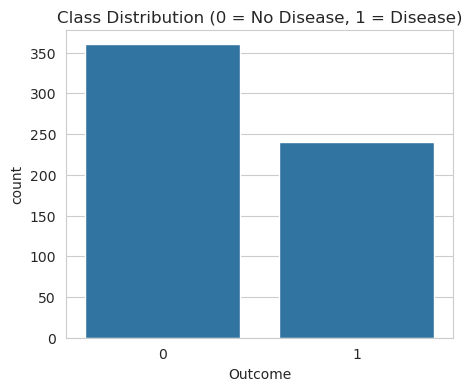

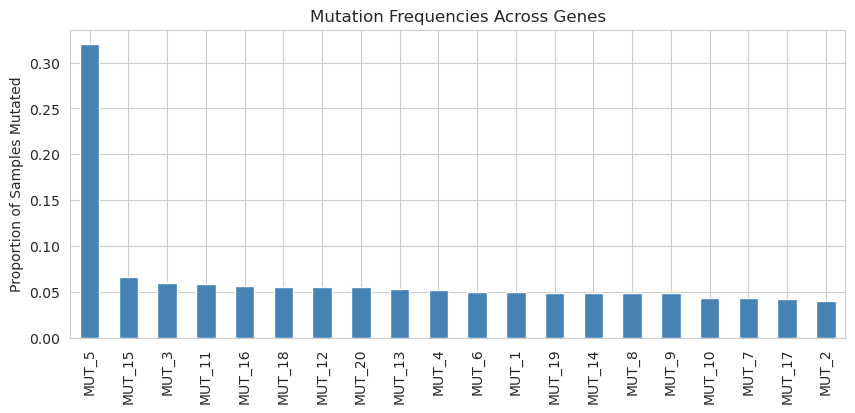

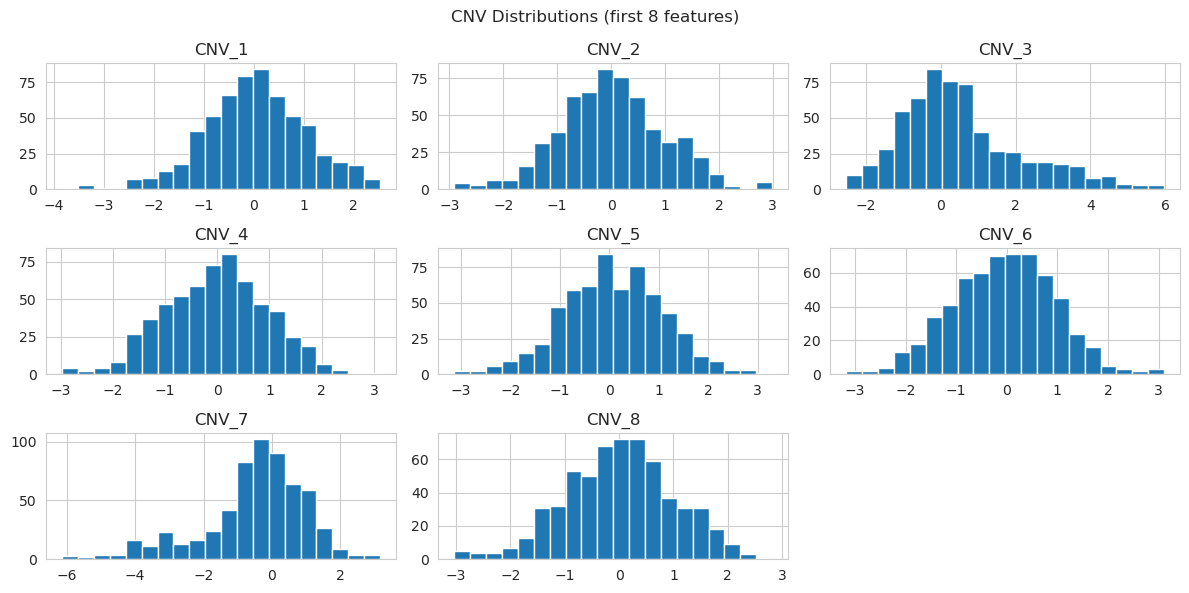

In [5]:
# 1) Class balance — how many diseased vs. healthy patients?
plt.figure(figsize=(5, 4))
sns.countplot(x="Outcome", data=df)
plt.title("Class Distribution (0 = No Disease, 1 = Disease)")
plt.show()

# 2) Mutation frequencies — which genes are mutated most often?
mut_freqs = df[mut_features].mean().sort_values(ascending=False)
mut_freqs.plot(kind="bar", figsize=(10, 4), color="steelblue")
plt.title("Mutation Frequencies Across Genes")
plt.ylabel("Proportion of Samples Mutated")
plt.show()

# 3) CNV distributions — are copies gained or lost? (first 8 shown)
df[cnv_features[:8]].hist(figsize=(12, 6), bins=20)
plt.suptitle("CNV Distributions (first 8 features)")
plt.tight_layout()
plt.show()

### Reading these plots like a biologist 🧬

- **Slight class imbalance** (first plot): there are somewhat more of one class than the
  other. This matters — a model can look "accurate" just by guessing the majority class,
  which is why later we lean on **ROC-AUC** rather than plain accuracy.

- **Mutation sparsity** (second plot): a few genes are mutated often (likely **driver**
  mutations that push disease), while most are rare (**passenger** mutations, largely noise).
  This mirrors real cancer genomes.

- **CNV shapes** (third plot):
  - Most values cluster around **0** → normal copy number (expected — not every region is altered).
  - **`CNV_3`** shows strong **amplifications** (values > 3). In real biology this looks like
    **oncogene amplification** (e.g. *HER2*, *MYC*) → more copies → more expression → tumour growth.
  - **`CNV_7`** shows deep **deletions** (values < −3), consistent with **tumour-suppressor loss**
    (e.g. *TP53*, *PTEN*, *RB1*) → protective brakes removed → higher cancer risk.

> 💡 Already we suspect `CNV_3` and a handful of mutations carry real signal. Later, the
> models' **feature importance** will let us check that hunch quantitatively.

## 1.4 Split into training and testing sets ✂️

We must judge a model on data it has **never seen** — otherwise it can memorise instead of
learn. We hold back **30%** of patients as a test set. `stratify=y` keeps the same
disease/healthy ratio in both halves, and `random_state=42` makes the split reproducible.

In [6]:
X = df[feature_names]
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training patients: {X_train.shape[0]}   Testing patients: {X_test.shape[0]}")

Training patients: 420   Testing patients: 180


## 1.5 A familiar baseline: logistic regression 📏

You already know logistic regression, so it makes the perfect **reference point**. Any
fancier model (RF, SVM) should ideally *beat* this simple baseline — if it doesn't, the
extra complexity isn't earning its keep.

We'll score every model the same way: **ROC-AUC**, which measures how well the model
*ranks* diseased patients above healthy ones (1.0 = perfect, 0.5 = coin flip).

In [7]:
# max_iter is bumped up just so the solver comfortably converges on this data.
logreg = LogisticRegression(max_iter=5000, random_state=42)
logreg.fit(X_train, y_train)

logreg_auc = roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1])
print(f"Logistic Regression  ROC-AUC = {logreg_auc:.3f}   <-- baseline to beat")

Logistic Regression  ROC-AUC = 0.866   <-- baseline to beat


## 1.6 Handling class imbalance ⚖️

Back in the EDA we spotted a **slight class imbalance** — more healthy patients (`0`) than
diseased ones (`1`). In real genomics this is the *norm*, not the exception: disease cases,
rare variants, and responders are usually the **minority**. Left unchecked, a model can score
high just by leaning toward the majority class while quietly **missing the very patients we
most want to catch**.

### The main families of fixes 🧰

| Approach | Idea in one line | Trade-off |
|---|---|---|
| **Do nothing + right metric** | judge with **ROC-AUC / recall / F1**, not accuracy | simplest, but the model still learns from skewed data |
| **Class weights** | tell the model to *penalise* minority mistakes more (`class_weight="balanced"`) | no new data; built into RF, SVM, LogReg |
| **Random undersampling** | throw away some majority samples until balanced | fast, but **discards real data** |
| **Random oversampling** | duplicate minority samples until balanced | keeps all data, but **duplicates → overfitting** |
| **Synthetic oversampling (SMOTE)** | *invent* new, plausible minority samples by interpolating between real ones | richer than duplicating; the technique we'll use here |
| **Hybrid (e.g. SMOTETomek)** | SMOTE **+** clean up borderline overlaps | balances *and* tidies the boundary |

### Why SMOTE? 💡

**SMOTE** (*Synthetic Minority Over-sampling TEchnique*) doesn't copy-paste existing patients —
that just teaches the model the same rows twice. Instead, for each minority patient it finds its
nearest minority-class neighbours and creates a **brand-new synthetic patient somewhere on the
line between them**. The result is a fuller, more varied picture of the minority class without
the naive over-fitting of plain duplication.

> ⚠️ **The one rule you must never break:** only balance the **training** data. The **test set**
> must keep its real-world class ratio, or your evaluation becomes a comforting lie.

Before SMOTE (training set):
Outcome
No Disease    252
Disease       168

After SMOTE (training set): 504 patients (was 420)
Outcome
Disease       252
No Disease    252


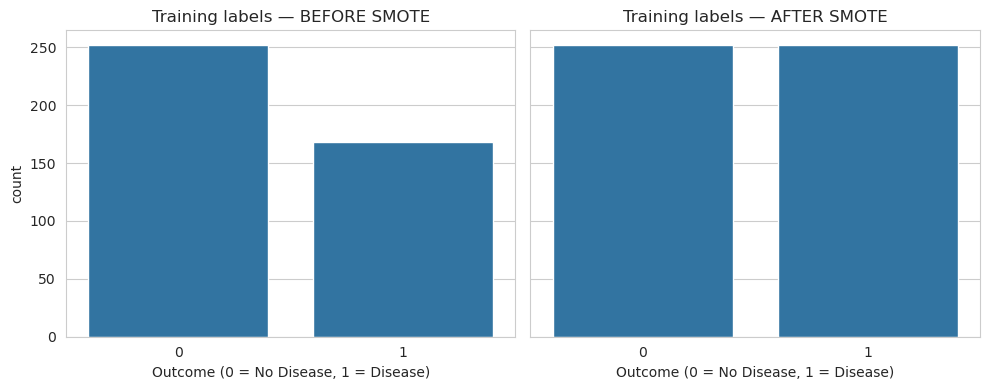

In [8]:
# SMOTE lives in the imbalanced-learn package (a scikit-learn companion), NOT sklearn itself.
# If the import fails, install it first:  pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# ── The GOLDEN RULE of resampling ──────────────────────────────────────────────
# Only ever balance the TRAINING data. The test set must keep the real-world class
# ratio, otherwise the score is flattering but fake. So we resample X_train / y_train
# into a *new* balanced copy and leave X_test / y_test completely untouched.
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE (training set):")
print(y_train.value_counts().rename({0: "No Disease", 1: "Disease"}).to_string())
print(f"\nAfter SMOTE (training set): {X_train_bal.shape[0]} patients "
      f"(was {X_train.shape[0]})")
print(y_train_bal.value_counts().rename({0: "No Disease", 1: "Disease"}).to_string())

# Visualise the before/after class counts.
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
sns.countplot(x=y_train, ax=ax[0]).set_title("Training labels — BEFORE SMOTE")
sns.countplot(x=y_train_bal, ax=ax[1]).set_title("Training labels — AFTER SMOTE")
for a in ax:
    a.set_xlabel("Outcome (0 = No Disease, 1 = Disease)")
plt.tight_layout()
plt.show()

### Does it actually help? A quick before/after 🔬

Balancing is only worth doing if it changes results, so let's **prove it to ourselves**. We'll
train the *same* Random Forest twice — once on the original training set, once on the
SMOTE-balanced one — and compare them on the **identical, untouched test set**.

Pay attention to the **recall for the "Disease" class** and the **confusion matrices** rather
than just the headline ROC-AUC.

=== Random Forest WITHOUT SMOTE (imbalanced training) ===
              precision    recall  f1-score   support

  No Disease       0.82      0.86      0.84       108
     Disease       0.78      0.72      0.75        72

    accuracy                           0.81       180
   macro avg       0.80      0.79      0.79       180
weighted avg       0.80      0.81      0.80       180

ROC-AUC = 0.875

=== Random Forest WITH SMOTE (balanced training) ===
              precision    recall  f1-score   support

  No Disease       0.88      0.76      0.82       108
     Disease       0.70      0.85      0.77        72

    accuracy                           0.79       180
   macro avg       0.79      0.80      0.79       180
weighted avg       0.81      0.79      0.80       180

ROC-AUC = 0.867


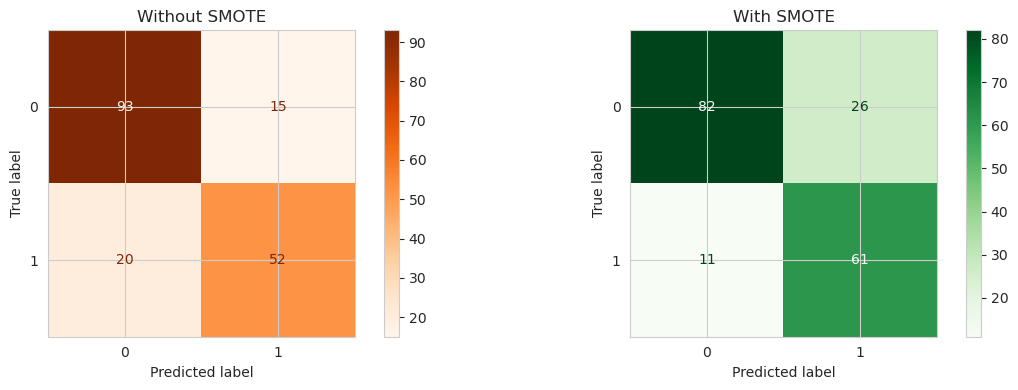

In [9]:
# Does balancing actually help? Train the SAME Random Forest two ways and compare.
# NB: we evaluate BOTH on the identical, untouched X_test / y_test.

# 1) Baseline: trained on the original (imbalanced) training set.
rf_plain = RandomForestClassifier(random_state=42)
rf_plain.fit(X_train, y_train)

# 2) SMOTE: trained on the synthetically balanced training set.
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_bal, y_train_bal)

print("=== Random Forest WITHOUT SMOTE (imbalanced training) ===")
print(classification_report(y_test, rf_plain.predict(X_test),
                            target_names=["No Disease", "Disease"]))
print(f"ROC-AUC = {roc_auc_score(y_test, rf_plain.predict_proba(X_test)[:, 1]):.3f}\n")

print("=== Random Forest WITH SMOTE (balanced training) ===")
print(classification_report(y_test, rf_smote.predict(X_test),
                            target_names=["No Disease", "Disease"]))
print(f"ROC-AUC = {roc_auc_score(y_test, rf_smote.predict_proba(X_test)[:, 1]):.3f}")

# Confusion matrices side-by-side so the shift in errors is easy to see.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_estimator(rf_plain, X_test, y_test, ax=ax[0], cmap="Oranges")
ax[0].set_title("Without SMOTE")
ConfusionMatrixDisplay.from_estimator(rf_smote, X_test, y_test, ax=ax[1], cmap="Greens")
ax[1].set_title("With SMOTE")
plt.tight_layout()
plt.show()

### Reading the comparison 📖

Watch the **recall for "Disease"** (class 1) especially. SMOTE typically pushes the forest to
**catch more of the minority-class patients** (higher recall), usually trading away a little
**precision** (a few more false alarms). The overall ROC-AUC may barely move — balancing is
mostly about *where* the model spends its errors, not always about a bigger headline score.

Whether that trade is worth it is a **clinical judgement call**, not a purely statistical one:
in disease screening, *missing* a sick patient is often far worse than a false alarm, so a
recall gain can matter even at the cost of precision.

**When SMOTE shines** 🌟
- moderate-to-severe imbalance where the **minority class is the one you care about**
- enough minority samples that "nearest neighbours" are still meaningful

**Handle with care** ⚠️
- **Never resample the test set** (we didn't — and neither should you). Fit SMOTE *inside*
  cross-validation too; `imblearn.pipeline.Pipeline` does this correctly and prevents leakage.
- SMOTE *interpolates* between samples, so for our **binary mutation flags** it can invent odd
  fractional "half-mutated" values. `SMOTENC` handles mixed categorical + numeric features
  more gracefully.
- Under extreme imbalance (<1%), pair SMOTE with a little undersampling, or simply reach for
  `class_weight="balanced"` (built into RF, SVM and LogReg) — sometimes the simplest fix wins.

> 🧬 **Bottom line:** balancing is a *tool*, not a reflex. Always compare against a plain
> baseline **and** the `class_weight="balanced"` option before committing to synthetic data.

# Part 2 — Random Forest 🌲

Time for our first "real" model. We'll build the intuition, train it, tune it, and then
read off which genomic features it found most important.

## 2.1 How a Random Forest works

**Step 1 — a single decision tree.** A decision tree asks a chain of yes/no questions
about the features and follows the branches to a decision:

```
                Is CNV_3 > 2.5 ?
                 /           \
               yes            no
               /               \
      Is MUT_5 == 1 ?       predict: No disease
        /       \
      yes        no
      /           \
  Disease      No disease
```

One tree is easy to read but **unstable** — change the data slightly and it can flip.

**Step 2 — build a whole forest.** A Random Forest grows **many** trees, and adds two
clever sources of randomness so the trees don't all look the same:

- **Bagging (bootstrap sampling):** each tree is trained on a random *resample* of patients.
- **Random feature subsets:** at each question, a tree may only choose from a random handful
  of features.

**Step 3 — vote.** To classify a new patient, every tree votes, and the **majority wins**.
Averaging many noisy-but-independent opinions cancels out their individual errors — this is
why the forest is far more robust than any single tree.

> 🧬 **Why biologists love it:** it copes with lots of features, needs no feature scaling,
> handles CNV (continuous) and mutation (binary) columns side-by-side, and reports **feature
> importance** so you can trace a prediction back to the underlying biology.

## 2.2 Train a baseline Random Forest

We start with sensible defaults (`random_state=42` for reproducibility) and evaluate with a
**classification report**, **ROC-AUC**, a **confusion matrix**, and a **ROC curve**.

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       108
           1       0.78      0.72      0.75        72

    accuracy                           0.81       180
   macro avg       0.80      0.79      0.79       180
weighted avg       0.80      0.81      0.80       180

Random Forest ROC-AUC = 0.875


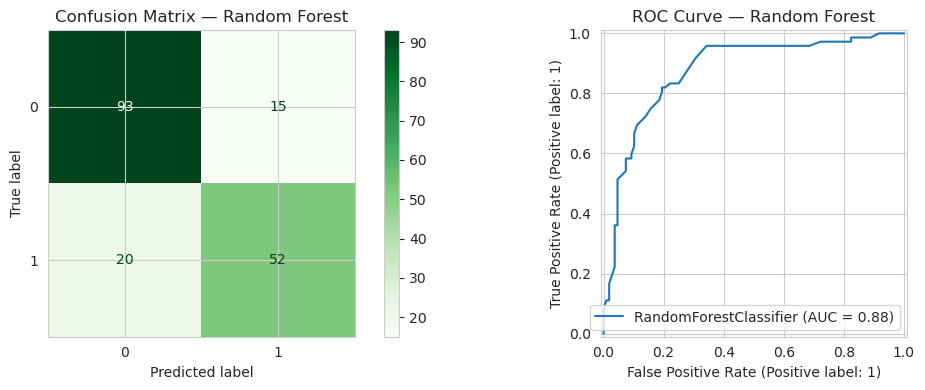

In [10]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)                       # <-- training happens here

y_pred_rf = rf.predict(X_test)                 # class predictions (0/1)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(classification_report(y_test, y_pred_rf))
print(f"Random Forest ROC-AUC = {rf_auc:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=ax[0], cmap="Greens")
ax[0].set_title("Confusion Matrix — Random Forest")
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax[1])
ax[1].set_title("ROC Curve — Random Forest")
plt.tight_layout()
plt.show()

### How to read these results 📖

- **Classification report:** *precision* = of those we flagged as diseased, how many truly
  were; *recall* = of the truly diseased, how many we caught; *f1* balances the two.
- **Confusion matrix:** the diagonal is correct calls; off-diagonal are mistakes
  (top-right = false alarms, bottom-left = missed cases).
- **ROC-AUC:** an AUC around **0.85–0.90** means **very good** ability to separate diseased
  from healthy patients. Compare it to our logistic baseline — the forest should be competitive
  or better.

## 2.3 Hyperparameter tuning — turning the knobs 🎛️

A model has two kinds of settings:
- **Parameters** the model *learns* from data (the tree splits themselves).
- **Hyperparameters** *we* choose before training. Good choices can meaningfully improve results.

### The concept: cross-validation

We can't tune on the test set (that would be cheating). Instead we use **k-fold
cross-validation** on the *training* data: split it into `k` parts, train on `k−1` and
validate on the held-out part, rotate, and average. This gives an honest performance
estimate for each combination of settings **without ever touching the test set**.

**`GridSearchCV`** automates this: give it a grid of settings and it tries every combination,
scoring each with cross-validation.

### The Random Forest knobs we'll tune

| Hyperparameter | What it controls | Too small → | Too large → |
|----------------|------------------|-------------|-------------|
| `n_estimators` | number of trees in the forest | unstable, noisy votes | slower, little extra gain |
| `max_depth` | how many questions deep each tree can go | **underfit** (too simple) | **overfit** (memorises noise) |
| `max_features` | how many features each split may consider | trees too similar | trees too similar/slow |

> ⚖️ **Underfitting vs. overfitting** is the central tension of tuning: too simple and the
> model misses real patterns; too complex and it memorises noise that won't generalise.
> Cross-validation is how we find the sweet spot.

In [11]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,                 # 5-fold cross-validation
    scoring="roc_auc",    # optimise the metric we actually care about
    n_jobs=-1             # use all CPU cores
)
grid_rf.fit(X_train, y_train)

print("Best settings found:", grid_rf.best_params_)
print(f"Best cross-validated ROC-AUC: {grid_rf.best_score_:.3f}")

# Evaluate the tuned forest on the untouched test set.
best_rf = grid_rf.best_estimator_
best_rf_auc = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
print(f"Tuned Random Forest ROC-AUC on TEST set: {best_rf_auc:.3f}")

Best settings found: {'max_depth': 5, 'max_features': 'log2', 'n_estimators': 200}
Best cross-validated ROC-AUC: 0.819
Tuned Random Forest ROC-AUC on TEST set: 0.877


## 2.4 Feature importance — reconnecting to biology 🧬

The best part for a biologist: the forest can tell us **which features drove its decisions**.
We use two complementary measures.

- **Gini importance** (fast, computed while training): how much each feature reduced impurity
  across all trees. Handy, but can be biased toward high-variance/continuous features.
- **Permutation importance** (computed after training): shuffle one feature and see how much
  performance *drops*. More trustworthy, and measured on the **test set**.

If both methods agree a feature matters, that's a strong signal worth taking to the lab bench.

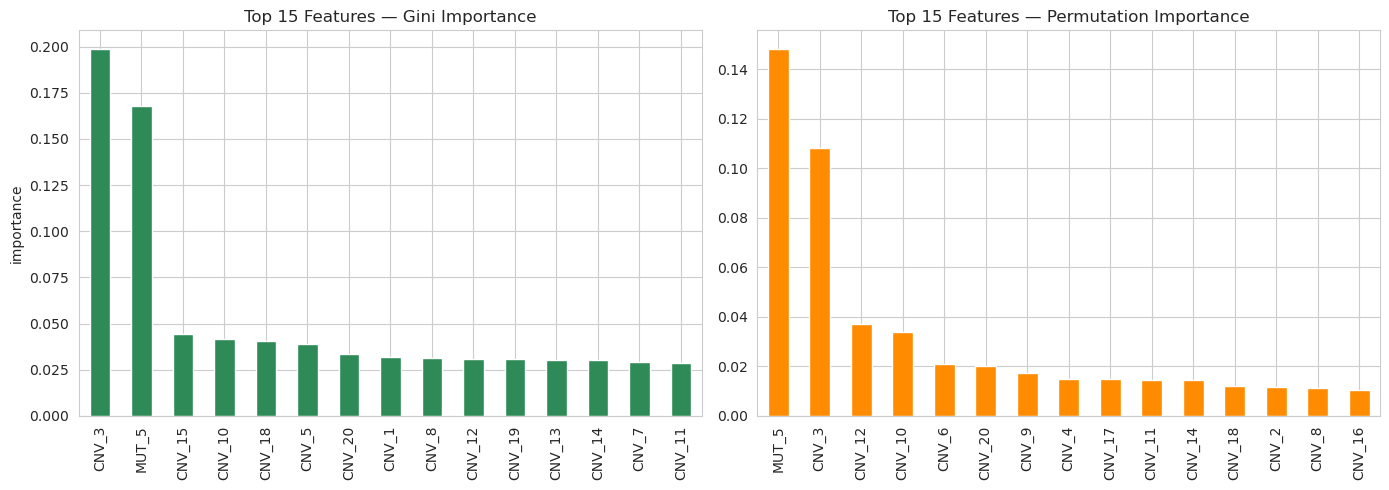

Top 5 by Gini:        ['CNV_3', 'MUT_5', 'CNV_15', 'CNV_10', 'CNV_18']
Top 5 by Permutation: ['MUT_5', 'CNV_3', 'CNV_12', 'CNV_10', 'CNV_6']


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gini importance
gini = pd.Series(best_rf.feature_importances_, index=feature_names)
gini.sort_values(ascending=False).head(15).plot(kind="bar", ax=ax[0], color="seagreen")
ax[0].set_title("Top 15 Features — Gini Importance")
ax[0].set_ylabel("importance")

# Permutation importance (on the test set)
perm = permutation_importance(best_rf, X_test, y_test, n_repeats=10,
                              random_state=42, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=feature_names)
perm_s.sort_values(ascending=False).head(15).plot(kind="bar", ax=ax[1], color="darkorange")
ax[1].set_title("Top 15 Features — Permutation Importance")

plt.tight_layout()
plt.show()

print("Top 5 by Gini:       ", list(gini.sort_values(ascending=False).head(5).index))
print("Top 5 by Permutation:", list(perm_s.sort_values(ascending=False).head(5).index))

### Interpreting the importance plots

- Features like **`CNV_3`** and **`MUT_5`** typically rise to the top — exactly the
  amplification and driver-mutation signals we suspected during EDA.
- The two methods won't rank things identically (Gini can over-credit continuous CNVs;
  permutation is stricter). **Trust features that score highly on *both*.**
- Low-ranked features are likely **noise / passenger** signals — biologically uninteresting here.

> 🧬 **This is the bridge from prediction back to biology:** a top-ranked, reproducible
> feature is a hypothesis — "does this gene's amplification/mutation actually drive the
> disease?" — that you can go and test experimentally.

# Part 3 — Support Vector Machine 🔷

Now the second philosophy: instead of a voting crowd, find the **single best boundary**.

## 3.1 How an SVM works

**The margin idea.** Picture the diseased and healthy patients as points. Many lines could
separate them — but an SVM picks the one dividing line with the **widest empty "street"**
(the *margin*) on either side. A wide margin means the boundary is confident and generalises
better.

```
   healthy  o   o        |<-- margin -->|        x  x   diseased
            o     o    [ - - boundary - - ]     x    x
         o    o           |<-- margin -->|         x   x
                          ^                ^
                    support vectors (points on the edge)
```

**Support vectors.** Only the handful of points sitting right on the edge of the street
actually determine the boundary — these are the **support vectors**. Every other patient
could move around freely without changing the line. That's what makes SVMs efficient and
focused.

**When the data isn't separable by a straight line — the kernel trick.** Real biology is
rarely linearly separable. The **kernel trick** lets the SVM bend the boundary by implicitly
lifting the data into a higher-dimensional space where a straight cut *does* separate the
classes. The popular **RBF (radial basis function)** kernel creates smooth, curved boundaries.

- **`C`** — how much we punish misclassified points. *Small `C`* = wider, softer margin
  (tolerates some errors, simpler boundary); *large `C`* = narrow, hard margin (fits training
  data tightly, risks overfitting).
- **`gamma`** — the "reach" of each point under the RBF kernel. *Small `gamma`* = smooth,
  broad boundary; *large `gamma`* = wiggly boundary that hugs individual points (overfitting risk).

## 3.2 Why SVMs need feature scaling (but Random Forests don't) ⚖️

This is the single most important practical difference to remember.

An SVM measures **distances** between points to find its margin. Our features live on wildly
different scales: **CNV** values range roughly from −4 to +4, while **MUT** values are only
0 or 1. Without scaling, the large-range CNV features would **dominate the distance calculation**
and the mutations would be almost ignored — not because they're unimportant, but purely because
their numbers are smaller.

**The fix:** `StandardScaler` rescales every feature to mean 0 and standard deviation 1, so all
features get a fair say. Random Forests don't need this — a tree's yes/no questions
(`CNV_3 > 2.5?`) don't care about scale at all.

> 🔧 **Best practice:** wrap the scaler and the model in a **`Pipeline`**. The pipeline learns
> the scaling from the *training* folds only and re-applies it consistently, which prevents
> "data leakage" from the test set during cross-validation.

              precision    recall  f1-score   support

           0       0.76      0.83      0.80       108
           1       0.71      0.61      0.66        72

    accuracy                           0.74       180
   macro avg       0.74      0.72      0.73       180
weighted avg       0.74      0.74      0.74       180

Baseline SVM (RBF) ROC-AUC = 0.835


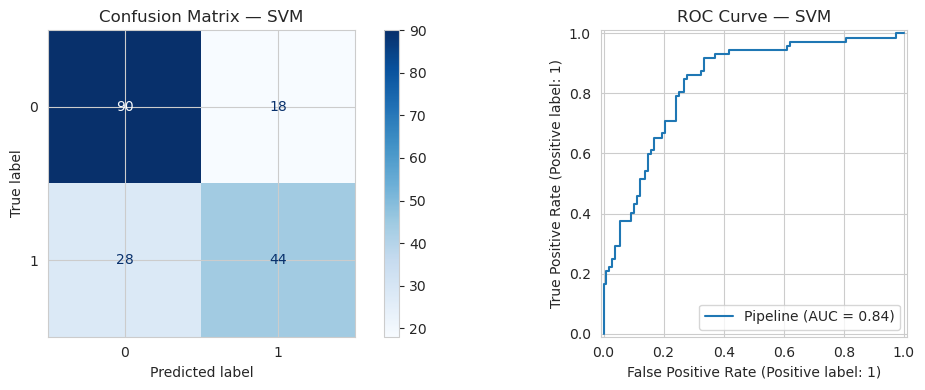

In [13]:
# A Pipeline chains steps: first scale, then feed the scaled data to the SVM.
# decision_function gives each patient a signed distance from the boundary
# (positive = disease side). roc_auc_score can rank patients with that score,
# so we don't need probabilities -- which keeps training fast.
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", random_state=42)),
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)
svm_auc = roc_auc_score(y_test, svm_pipeline.decision_function(X_test))

print(classification_report(y_test, y_pred_svm))
print(f"Baseline SVM (RBF) ROC-AUC = {svm_auc:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_estimator(svm_pipeline, X_test, y_test, ax=ax[0], cmap="Blues")
ax[0].set_title("Confusion Matrix — SVM")
RocCurveDisplay.from_estimator(svm_pipeline, X_test, y_test, ax=ax[1])
ax[1].set_title("ROC Curve — SVM")
plt.tight_layout()
plt.show()

## 3.3 Tuning the SVM 🎛️

We tune the SVM inside the **same pipeline**, so scaling is re-learned correctly on every
cross-validation fold. Because the SVM steps live under the name `"svc"` in the pipeline, we
prefix each hyperparameter with `svc__` (that's a double underscore).

| Hyperparameter | What it controls | Small value | Large value |
|----------------|------------------|-------------|-------------|
| `C` | penalty for misclassified points | soft, wide margin (may underfit) | hard margin, tight fit (may overfit) |
| `gamma` | reach of the RBF kernel | smooth, simple boundary | wiggly, complex boundary |
| `kernel` | shape of the boundary | `linear` (straight) | `rbf` (curved) |

In [14]:
param_grid_svm = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.01, 0.1],
    "svc__kernel": ["rbf", "linear"],
}

grid_svm = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
grid_svm.fit(X_train, y_train)

print("Best settings found:", grid_svm.best_params_)
print(f"Best cross-validated ROC-AUC: {grid_svm.best_score_:.3f}")

best_svm = grid_svm.best_estimator_
best_svm_auc = roc_auc_score(y_test, best_svm.decision_function(X_test))
print(f"Tuned SVM ROC-AUC on TEST set: {best_svm_auc:.3f}")

Best settings found: {'svc__C': 0.1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Best cross-validated ROC-AUC: 0.820
Tuned SVM ROC-AUC on TEST set: 0.868


### A note on SVM interpretability 🔍

Unlike Random Forests, an SVM (especially with an RBF kernel) does **not** hand you a clean
"feature importance" list — its decision lives in a transformed space that doesn't map back
to single genes. This is the classic **accuracy-vs-interpretability trade-off**: SVMs can draw
excellent boundaries but are harder to explain biologically. If you need per-gene importance,
**permutation importance** can still be applied to the fitted SVM, or you can lean on the
Random Forest for the biological story.

# Part 4 — Head-to-Head: Which Model Wins? 🏆

We've trained three models the same way, on the same split, scored with the same metric.
Let's line them up.

                         Model  Test ROC-AUC
         Random Forest (tuned)         0.877
             SVM / RBF (tuned)         0.868
Logistic Regression (baseline)         0.866


/tmp/claude-1000/ipykernel_2318800/781311012.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Test ROC-AUC", y="Model", palette="viridis")


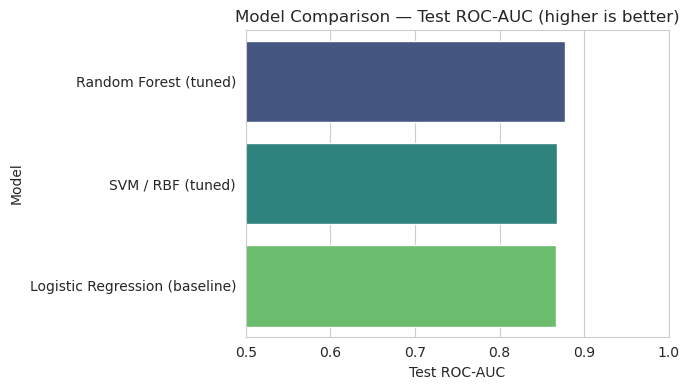

In [15]:
results = pd.DataFrame({
    "Model": ["Logistic Regression (baseline)", "Random Forest (tuned)", "SVM / RBF (tuned)"],
    "Test ROC-AUC": [round(logreg_auc, 3), round(best_rf_auc, 3), round(best_svm_auc, 3)],
})
results = results.sort_values("Test ROC-AUC", ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=results, x="Test ROC-AUC", y="Model", palette="viridis")
plt.xlim(0.5, 1.0)          # 0.5 = random guessing
plt.title("Model Comparison — Test ROC-AUC (higher is better)")
plt.tight_layout()
plt.show()

## 4.1 Choosing a model — it's not only about the score

| | 🌲 Random Forest | 🔷 SVM (RBF) | 📏 Logistic Regression |
|---|---|---|---|
| **Boundary style** | many voting trees | one widest-margin boundary | single straight (log-odds) line |
| **Needs feature scaling?** | ❌ No | ✅ **Yes** (essential) | Helpful, not critical |
| **Handles non-linear patterns?** | ✅ Yes | ✅ Yes (via kernel) | ⚠️ Limited |
| **Feature importance?** | ✅ Built-in (Gini + permutation) | ⚠️ Only via permutation | ✅ Coefficients |
| **Interpretability** | 🟢 Good | 🔴 Harder | 🟢 Good |
| **Main knobs to tune** | `n_estimators`, `max_depth`, `max_features` | `C`, `gamma`, `kernel` | `C` (regularisation) |

### Practical guidance for genomic work 🧬

- **Want to know *which genes* drive the prediction?** → Random Forest (feature importance is a gift for biology).
- **Chasing the strongest possible boundary and willing to preprocess + tune carefully?** → SVM.
- **Need a fast, transparent starting point / sanity check?** → Logistic regression.

> 🏁 **Golden rule:** the "best" model is the one that balances **performance**,
> **interpretability**, and the **question you're actually asking**. A slightly less accurate
> model that tells you *why* is often more valuable in biology than a black box that's 1% better.

## 📝 Assignments

Work through these to cement the concepts, then write up your findings.

1. **Linear vs. logistic.** In your own words (2–3 sentences), explain why the linear-regression
   demo in Part 0 produced impossible predictions, and how logistic regression fixes it.
2. **Scaling experiment.** Re-run the SVM in Part 3 **without** the `StandardScaler` step
   (use a bare `SVC`). Does the ROC-AUC change? Explain *why*, connecting it to how SVMs use distance.
3. **Tune deeper.** Add another value to the Random Forest grid (e.g. `min_samples_leaf`) or the
   SVM grid, re-run the search, and report whether the tuned score improved.
4. **Biology check.** Take the top 3 features from the Random Forest importance plot. For each,
   state whether it's a CNV or a mutation and propose a plausible biological reason it could drive disease.
5. **Model choice.** Given the comparison table, which model would you deploy for a clinical
   screening tool, and which for a research study hunting new driver genes? Justify each choice.
6. **Write it up.** Summarise your results in a short PDF report, `Assignment-week16-17-done.pdf`,
   and push it to your branch on GitHub.

---
*Happy modelling! Remember: a model is only as trustworthy as your understanding of what it's doing.* 🌲🔷